In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
data=pd.read_csv("Student Depression Dataset.csv")
data

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [11]:
print("Dataset Shape:")
print(data.shape)
print("\nMissing Values:")
print(data.isnull().sum())
print("\nDuplicate Rows:")
print(data.duplicated().sum())
data=data.drop_duplicates()

Dataset Shape:
(27901, 18)

Missing Values:
id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

Duplicate Rows:
0


In [12]:
print(data.head())
print(data.columns)

   id  Gender   Age           City Profession  Academic Pressure  \
0   2    Male  33.0  Visakhapatnam    Student                5.0   
1   8  Female  24.0      Bangalore    Student                2.0   
2  26    Male  31.0       Srinagar    Student                3.0   
3  30  Female  28.0       Varanasi    Student                3.0   
4  32  Female  25.0         Jaipur    Student                4.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  8.97                 2.0               0.0   
1            0.0  5.90                 5.0               0.0   
2            0.0  7.03                 5.0               0.0   
3            0.0  5.59                 2.0               0.0   
4            0.0  8.13                 3.0               0.0   

      Sleep Duration Dietary Habits   Degree  \
0          5-6 hours        Healthy  B.Pharm   
1          5-6 hours       Moderate      BSc   
2  Less than 5 hours        Healthy       BA   
3          7-8

In [5]:
X=data[["Age", "Academic Pressure", "Study Satisfaction", "Work/Study Hours", "Financial Stress"]]

In [7]:
X=X.fillna(X.mean())

In [13]:
print("\nMissing Values After cleaning:")
print(X.isnull().sum())


Missing Values After cleaning:
Age                   0
Academic Pressure     0
Study Satisfaction    0
Work/Study Hours      0
Financial Stress      0
dtype: int64


In [8]:
y=data["Depression"]

In [27]:
print("\nMissing Values in Target Variable:")
print(y.isnull().sum())


Missing Values in Target Variable:
0


In [17]:
model=GaussianNB()
model.fit(X, y)

GaussianNB()

In [26]:
pred=model.predict(X)

In [32]:
acc=accuracy_score(y, pred)
print("Accuracy Score:",acc*100,"%")
print("\nModel trained successfully using Gaussian Naive Bayes")

Accuracy Score: 78.79287480735458 %

Model trained successfully using Gaussian Naive Bayes


In [20]:
cm=confusion_matrix(y, pred)
print("Confusion matrix:")
print(cm)

Confusion matrix:
[[ 8289  3276]
 [ 2641 13695]]


In [21]:
age=float(input("Enter Age: "))
academic_pressure=float(input("Enter Academic Pressure (1-5): "))
study_satisfaction=float(input("Enter Study Satisfaction (1-5): "))
work_hours=float(input("Enter Work/Study Hours: "))
financial_stress=float(input("Enter Financial Stress (1-5): "))
test_student=pd.DataFrame({"Age":[age], "Academic Pressure":[academic_pressure], "Study Satisfaction":[study_satisfaction], "Work/Study Hours":[work_hours], "Financial Stress":[financial_stress]})

Enter Age:  21
Enter Academic Pressure (1-5):  5
Enter Study Satisfaction (1-5):  2
Enter Work/Study Hours:  10
Enter Financial Stress (1-5):  5


In [22]:
prediction=model.predict(test_student)
print("Predicted Result:",prediction[0])

Predicted Result: 1


In [23]:
if prediction[0]==1:
    print("Student may be depressed")
else:
    print("Student may not be depressed")

Student may be depressed


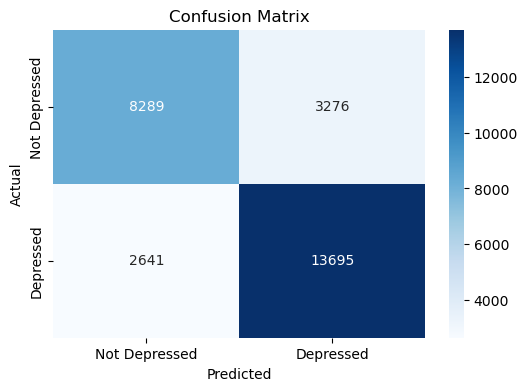

In [25]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Depressed','Depressed'], yticklabels=['Not Depressed','Depressed'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [73]:
# Project Name: MindGuard
# Objective: To predict whether a student may be depressed based on academic and lifestyle factors using Gaussian Naive Bayes Classification.
# Accuracy Score: 78.79%
# Outcome: The model successfully classified students into depressed and non-depressed categories and was evaluated using a confusion matrix.